In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


pd.set_option("display.max_columns", None)

In [3]:
data= pd.read_csv(r'C:\Users\HP\Desktop\10NALYTICS LMS CLASSES\AMDARI PROJECTS\Novapay-Fraudulent\data\nova_pay_combined.csv', parse_dates=['timestamp'])

In [4]:
data.head(5) # Display the first 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
data.tail(5) # Display the last 5 rows of the DataFrame

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11395,b5ef3323-46d2-4f6c-9c19-43df4e55df48,8734e6a7-f34e-49f2-b559-1d62a756664c,2025-11-25 10:05:35.573611+00:00,US,USD,CAD,mobile,271.25,271.25,5.24,1.351351,5c06f00d-a089-402b-9b14-e7bc7ae56ed2,False,221.126.239.197,US,False,0.307,standard,742,0.653,0,0.302,1,2,0.00,0
11396,54f00f78-94aa-4a08-bf6b-12877aa47186,c18070a6-bdb9-4df3-9df7-5d92c0bff424,2025-11-26 07:09:56.573611+00:00,CA,CAD,NGN,web,537.17,397.51,8.86,822.222222,dafd943c-f12f-48b9-83df-401efaad0fe3,False,26.6.123.44,UK,True,0.891,low,9,0.173,2,0.730,3,6,0.00,1
11397,6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5,2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca,2025-11-27 06:19:11.573611+00:00,CA,CAD,INR,web,205.15,151.81,4.00,61.666667,94475656-37f3-4b9c-b3cd-6d89416866ac,True,184.150.56.237,US,True,1.000,low,21,0.269,1,0.605,3,4,0.12,1
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,0eab90ef-4273-4239-8b51-2c96b2a24756,False,31.125.175.93,US,False,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,1111.111111,1bf43786-477e-468a-9f82-4b4eeca13f61,True,216.205.157.160,US,False,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [6]:
data.shape # Display the shape of the DataFrame (number of rows and columns)

(11400, 26)

In [7]:
data.columns # Display the column names of the DataFrame

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'amount_src',
       'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id',
       'new_device', 'ip_address', 'ip_country', 'location_mismatch',
       'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'is_fraud'],
      dtype='str')

In [8]:
data.info() # Display information about the DataFrame, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  str    
 1   customer_id                11400 non-null  str    
 2   timestamp                  11371 non-null  str    
 3   home_country               11400 non-null  str    
 4   source_currency            11400 non-null  str    
 5   dest_currency              11400 non-null  str    
 6   channel                    11400 non-null  str    
 7   amount_src                 11400 non-null  str    
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  str    
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  str    
 14  i

### Comment/Observation

The dataset contains 11,400 transactions and 26 columns, with a mixture of numerical, categorical, Boolean, and identifier variables. Most columns are complete, but the following displayed columns contain missing values:

timestamp — 29 missing values, 
amount_usd — 305 missing values,
fee — 295 missing values,
ip_address — 305 missing values,
ip_country — 301 missing values,
kyc_tier — 300 missing values,
device_trust_score — 295 missing values.

In [9]:
data.describe() # Display summary statistics for numerical columns in the DataFrame

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11095.000000,11105.000000,11400.000000,11400.000000,11400.000000,11105.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000,11400.000000
mean,452.022083,100.309441,167.540397,0.396726,393.793158,0.653681,0.048509,0.267134,0.458333,0.723509,0.045501,0.087456
std,1403.973062,958.128504,382.023827,0.270507,342.348393,0.273012,0.256194,0.142983,1.524494,1.958390,0.084942,0.282515
min,7.230000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,92.465000,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,163.480000,3.500000,7.142857,0.325000,298.000000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,302.190000,5.550000,73.529412,0.487000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


### Comment/Observation

The descriptive statistics show that the dataset contains several highly skewed numerical variables and possible data-quality issues and investivated to chech for outliers. Example; amount_usd has a mean of $452.02 but a median of only $163.48, with a maximum of $12,498.57, indicating that most transactions are relatively small while a few unusually large transactions increase the average.

The numerical variables are generally highly skewed, particularly amount_usd and fee, where a few extreme values have raised the mean above the median. Some values, such as negative fees, negative device trust scores, IP risk scores above 1, and negative hourly transaction velocity, may represent errors or special codes and will be investigated. Most customers have no chargeback history or recent transaction activity. The fraud rate is approximately 8.75%, indicating that the target variable is imbalanced and will be handled carefully during modelling.

### 1. Data Cleaning and Investigation

I Started with identifying and correcting missing values, dupliate transactions, invalid records and inconsistent data. Then proceeded to investigate invalid values, outliers, categorical inconsistencies and logical relationships. This will help me prepare NovaPay’s transaction dataset for accurate fraud analysis and machine-learning modelling.

In [10]:
missing_values = data.isnull().sum() # Calculate the number of missing values for each column in the DataFrame
missing_percentage = data.isnull().mean() * 100 # Calculate the percentage of missing values for each column in the DataFrame

pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
amount_usd,305,2.68
ip_address,305,2.68
ip_country,301,2.64
kyc_tier,300,2.63
device_trust_score,295,2.59
fee,295,2.59
timestamp,29,0.25
transaction_id,0,0.00
customer_id,0,0.00
home_country,0,0.00


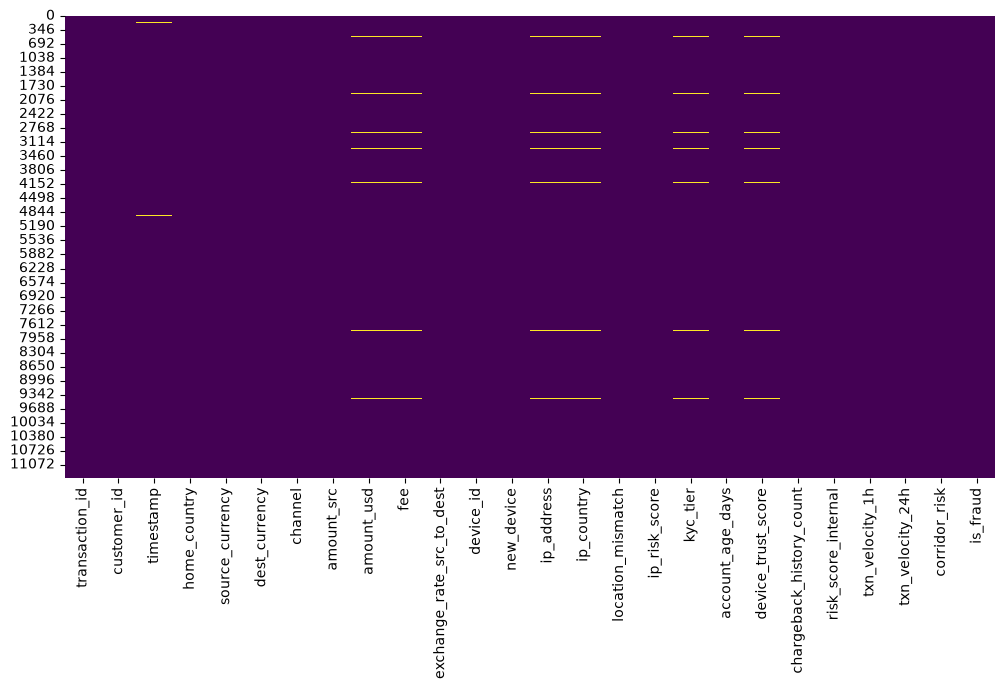

In [11]:
plt.figure(figsize=(12, 6)) # Create a figure with a specified size
sns.heatmap(data.isnull(), cbar=False, cmap='viridis'); # Create a heatmap to visualize missing values

In [12]:
data[data.isnull().any(axis=1)] # Display rows with any missing values

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
13,1a34a095-3be4-4a69-a22e-803be566526c,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-10-05 07:04:39.468549+00:00,UK,GBP,EUR,mobile,322.24,NaN,NaN,1.157407,9957de24-ace9-4938-bb81-6e7e41276961,False,NaN,NaN,False,0.245,NaN,4,NaN,0,0.407,0,0,0.05,0
49,b489474c-b729-4759-86e9-51778ddea385,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-08 20:45:48.468549+00:00,US,USD,INR,mobile,255.06,NaN,NaN,83.333333,b823bda8-e2a3-4541-a8d3-ae59fc963dd7,False,NaN,NaN,False,0.530,NaN,263,NaN,0,0.223,0,0,0.00,0
151,32cbd613-5c6c-4797-be15-165bc408c2ca,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-20 22:08:59.468549+00:00,US,USD,MXN,mobile,502.97,NaN,NaN,17.241379,8d9e4e31-6e23-4e66-904f-4eb99949ef18,False,NaN,NaN,False,0.310,NaN,1018,NaN,0,0.087,0,0,0.20,0
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,58.823529,a662fddf-fd9e-4b0d-9dd7-4b5371532e31,False,239.110.89.38,US,False,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,7.142857,2359adc2-91bf-4f51-80e8-3602dad715fe,False,29.203.81.123,US,False,0.353,standard,298,0.336,0,0.166,0,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10054,35da0a3e-5776-4f7e-b102-5ea3d5034713,402cccc9-28de-45b3-9af7-cc5302aa1f93,2025-06-20 07:38:53.468549+00:00,US,USD,EUR,mobile,9993.94,NaN,NaN,0.925926,b3290ccd-926f-4e98-b219-eab283ad718a,False,NaN,NaN,False,0.434,NaN,263,NaN,0,0.223,0,0,0.00,0
10082,adc74103-d3b7-491e-a3c9-02aae2050d46,7bd5200c-5d19-44f0-9afe-8b339a05366b,2025-01-27 17:14:38.468549+00:00,US,USD,USD,mobile,414.29,NaN,NaN,1.000000,eb8cac8c-da67-4a9a-84c9-e67242be9cbd,False,NaN,NaN,False,0.446,NaN,147,NaN,0,0.391,0,0,0.00,1
10093,d5ce08b7-d78f-4e1b-97c0-362cc64e12ee,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2024-06-28 06:10:20.468549+00:00,US,USD,PHP,mobile,125.75,NaN,NaN,58.823529,991bd49b-7d62-4ac6-81bf-b2e16aa7c0f2,False,NaN,NaN,False,0.451,NaN,1018,NaN,0,0.087,0,0,0.10,0
10142,356a1a21-e76c-4ad6-b712-405d3ad215e6,23d9943d-57b1-42eb-9ef2-05eed7fd1957,2024-03-04 21:11:40.468549+00:00,UK,GBP,INR,mobile,83.96,NaN,NaN,104.166667,1bbcba69-0f10-499b-9d26-3d9b59cc3dfc,False,NaN,NaN,False,0.474,NaN,718,NaN,0,0.169,0,0,0.00,0


## check duplicates and investigate the missing values before removing them

## Copy of Original Dataset

In [13]:
original_data = data.copy() # Create a copy of the original DataFrame to preserve the original data before any modifications
print("Original shape:", data.shape) # Display the shape of the original DataFrame

Original shape: (11400, 26)


In [14]:
print("Duplicate rows:", data.duplicated().sum()) # Check for duplicate rows in the DataFrame and display the count

Duplicate rows: 200


In [15]:
print(
    "Duplicate transaction IDs:",
    data["transaction_id"].duplicated().sum()
) # Check for duplicate transaction IDs in the DataFrame and display the count

Duplicate transaction IDs: 200


In [17]:
data.groupby("is_fraud").apply(
    lambda group: group.isnull().sum(),
    include_groups=False
) # Display the number of missing values for each column, grouped by the "is_fraud" column

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk
is_fraud,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,0,28,0,0,0,0,0,297,287,0,0,0,297,293,0,0,292,0,287,0,0,0,0,0
1,0,0,1,0,0,0,0,0,8,8,0,0,0,8,8,0,0,8,0,8,0,0,0,0,0


In [18]:
print("Rows before:", data.shape[0]) # Display the number of rows in the DataFrame before removing missing values

clean_data = data.dropna()

print("Rows after:", clean_data.shape[0])
print("Rows removed:", data.shape[0] - clean_data.shape[0])

Rows before: 11400
Rows after: 11066
Rows removed: 334


## Removing Duplicates

In [19]:
data = data.drop_duplicates().reset_index(drop=True) # Remove duplicate rows from the DataFrame and reset the index
print("Rows after cleaning:", len(data)) # Display the number of rows in the DataFrame after removing duplicates 

Rows after cleaning: 11200


## Removing Missing Values

In [20]:
data.dropna(inplace=True) # Drop rows with any missing values from the DataFrame
data.isnull().sum() # Check for missing values in the DataFrame after dropping rows with missing values

transaction_id               0
customer_id                  0
timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
device_id                    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
dtype: int64

In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 10871 entries, 0 to 11199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10871 non-null  str    
 1   customer_id                10871 non-null  str    
 2   timestamp                  10871 non-null  str    
 3   home_country               10871 non-null  str    
 4   source_currency            10871 non-null  str    
 5   dest_currency              10871 non-null  str    
 6   channel                    10871 non-null  str    
 7   amount_src                 10871 non-null  str    
 8   amount_usd                 10871 non-null  float64
 9   fee                        10871 non-null  float64
 10  exchange_rate_src_to_dest  10871 non-null  float64
 11  device_id                  10871 non-null  str    
 12  new_device                 10871 non-null  bool   
 13  ip_address                 10871 non-null  str    
 14  ip_cou

### Inconsistent categorical values

This checks spelling, capitalisation and unexpected categories.

In [ ]:
# Select all categorical/string columns
categorical_columns = data.select_dtypes(
    include=["object", "string", "category"]
).columns

# Exclude identifier columns because they contain many unique values
identifier_columns = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address"
]

categorical_columns = [
    column for column in categorical_columns
    if column not in identifier_columns
]

# Display the first 20 categories and their frequencies
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print("Number of unique values:", data[column].nunique(dropna=False))
    print(data[column].value_counts(dropna=False).head(20)) # Display the first 20 unique values and their frequencies for each categorical column


--- timestamp ---
Number of unique values: 10841
timestamp
0000-00-00T00:00:00Z                21
2025/13/40 25:61:00                 10
2024-01-22 00:24:24.468549+00:00     2
2022-10-03 18:40:59.468549+00:00     1
2022-10-03 20:39:38.468549+00:00     1
2022-10-03 23:02:43.468549+00:00     1
2022-10-04 01:08:53.468549+00:00     1
2022-10-04 09:35:03.468549+00:00     1
2022-10-04 12:09:59.468549+00:00     1
2022-10-04 12:37:41.468549+00:00     1
2022-10-04 16:27:44.468549+00:00     1
2022-10-04 21:00:36.468549+00:00     1
2022-10-04 21:20:42.468549+00:00     1
2022-10-04 22:18:42.468549+00:00     1
2022-10-04 22:54:28.468549+00:00     1
2022-10-05 00:57:43.468549+00:00     1
2022-10-05 13:34:02.468549+00:00     1
2022-10-05 15:32:41.468549+00:00     1
2022-10-05 17:13:30.468549+00:00     1
2022-10-05 19:41:37.468549+00:00     1
Name: count, dtype: int64

--- home_country ---
Number of unique values: 7
home_country
US         7557
UK         2019
CA         1180
 US          63
unknown 

### Clean and convert timestamp and Wrong Spellings

In [25]:
import pandas as pd

# Replace invalid date placeholders
data["timestamp"] = data["timestamp"].replace(
    ["0000-00-00T00:00:00Z", "0000-00-00 00:00:00"],
    pd.NA
)

# Convert timestamp from string to datetime
data["timestamp"] = pd.to_datetime(
    data["timestamp"],
    errors="coerce",
    utc=True,
    format="mixed"
)

print(data["timestamp"].dtype)
print("Missing/invalid timestamps:", data["timestamp"].isna().sum())

datetime64[us, UTC]
Missing/invalid timestamps: 31


In [ ]:
data["transaction_year"] = data["timestamp"].dt.year # Extract year from timestampdata["transaction_month"] = data["timestamp"].dt.month
data["transaction_day"] = data["timestamp"].dt.day_name() # Extract day of the week from timestamp
data["transaction_hour"] = data["timestamp"].dt.hour # Extract hour from timestamp
data["is_weekend"] = data["timestamp"].dt.dayofweek >= 5 # Identify weekend transactions

### Identify the column containing inconsistent values

In [ ]:
for column in data.select_dtypes(include=["object", "string"]).columns:
    values = data[column].astype("string").str.strip().str.lower()

    if values.isin(["low", "enhancd"]).any():
        print(f"\nColumn: {column}")
        print(data[column].value_counts(dropna=False)) # Display the value counts for columns with specific values ("low" or "enhancd")


Column: kyc_tier
kyc_tier
standard       7761
enhanced       1787
low            1032
standrd          72
STANDARD         69
 standard        64
unknown          28
 enhanced        17
ENHANCED         16
enhancd          12
 low              8
LOW               5
Name: count, dtype: int64


In [29]:
categorical_columns = data.select_dtypes(
    include=["object", "string", "category"]
).columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print("Unique values:", data[column].nunique(dropna=False))
    print(data[column].value_counts(dropna=False).head(10))


--- transaction_id ---
Unique values: 10871
transaction_id
fee8542d-8ee6-4b0d-9671-c294dd08ed26    1
bfdb9fc1-27fe-4a85-b043-4d813d679259    1
fc855034-3ea5-4993-9afa-b511d93fe5e8    1
2cf8c08e-42ec-444d-a755-34b9a2a0a4ca    1
d907a74d-b426-438d-97eb-dbe911aca91c    1
ec17d6f2-6505-4de9-910f-0de3ac3bbc23    1
2d8efe37-33ea-40de-9881-e553e3f2f8ce    1
4d311532-ee0b-4985-b996-63e11a7144d3    1
db5bdea7-0701-4c07-9efa-815fa6ca9ede    1
d74c81c0-bf5d-4184-8ce2-27fb753cb1c6    1
Name: count, dtype: int64

--- customer_id ---
Unique values: 1314
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1437
d71c91b4-fee8-4104-9856-a5c6109a62e3    1280
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1265
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1003
af8ca4c4-8703-4c55-b66c-2b76cd70040d     861
7bd5200c-5d19-44f0-9afe-8b339a05366b     777
70a93d26-8e3a-4179-900c-a4a7a74d08e5     646
f7531a78-8bbe-4a85-b1e8-a0650edddc72     368
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     339
23d9943d-57b1-42eb-9ef2-05eed7fd1957

In [ ]:
data["channel"] = data["channel"].str.strip().str.lower()
data["home_country"] = data["home_country"].str.strip().str.upper() # Normalize home country values to uppercase

In [ ]:
data[
    (data["home_country"] != data["ip_country"]) &
    (data["location_mismatch"] == False)
][["home_country", "ip_country", "location_mismatch"]] # Display rows where home_country and ip_country do not match, but location_mismatch is False

,home_country,ip_country,location_mismatch
278,US,US,False
640,US,US,False
670,US,US,False
712,UK,unknown,False
933,US,unknown,False
...,...,...,...
9557,US,US,False
9587,UNKNOWN,CA,False
9656,UK,unknown,False
9893,US,unknown,False


In [36]:
import pandas as pd

# Preserve the original location mismatch column for comparison
data["location_mismatch_original"] = data["location_mismatch"]

# Common country-name corrections
country_mapping = {
    "USA": "US",
    "UNITED STATES": "US",
    "UNITED STATES OF AMERICA": "US",
    "GB": "UK",
    "GBR": "UK",
    "GREAT BRITAIN": "UK",
    "UNITED KINGDOM": "UK"
}

# Values that should be treated as missing
unknown_values = [
    "",
    "UNKNOWN",
    "N/A",
    "NA",
    "NULL",
    "NONE",
    "-"
]

# Clean both country columns
for column in ["home_country", "ip_country"]:
    data[column] = (
        data[column]
        .astype("string")
        .str.strip()                  # Remove hidden spaces
        .str.upper()                  # Standardise capitalisation
        .replace(unknown_values, pd.NA)
        .replace(country_mapping)
    )

In [37]:
# Identify rows where both countries are available
known_countries = (
    data["home_country"].notna()
    & data["ip_country"].notna()
)

# Create a nullable Boolean column
data["location_mismatch"] = pd.Series(
    pd.NA,
    index=data.index,
    dtype="boolean"
)

# Recalculate mismatch only when both countries are known
data.loc[known_countries, "location_mismatch"] = (
    data.loc[known_countries, "home_country"]
    != data.loc[known_countries, "ip_country"]
)

In [ ]:
comparison = data[
    data["location_mismatch_original"].astype("boolean")
    != data["location_mismatch"]
][
    [
        "home_country",
        "ip_country",
        "location_mismatch_original",
        "location_mismatch"
    ]
]

print("Corrected mismatch records:", len(comparison))
comparison.head(20) # Display the first 20 corrected mismatch records

Corrected mismatch records: 20


,home_country,ip_country,location_mismatch_original,location_mismatch
10054,CA,CA,True,False
10072,US,US,True,False
10190,US,US,True,False
10258,US,US,True,False
10266,UK,UK,True,False
10273,US,US,True,False
10386,US,US,True,False
10427,US,US,True,False
10500,UK,UK,True,False
10528,US,US,True,False


In [40]:
data["customer_id"].value_counts().head(10) # Display the top 10 most frequent customer IDs and their counts

customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1437
d71c91b4-fee8-4104-9856-a5c6109a62e3    1280
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1265
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1003
af8ca4c4-8703-4c55-b66c-2b76cd70040d     861
7bd5200c-5d19-44f0-9afe-8b339a05366b     777
70a93d26-8e3a-4179-900c-a4a7a74d08e5     646
f7531a78-8bbe-4a85-b1e8-a0650edddc72     368
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad     339
23d9943d-57b1-42eb-9ef2-05eed7fd1957     333
Name: count, dtype: int64

In [41]:
data["device_id"].value_counts().head(10) # Display the top 10 most frequent device IDs and their counts

device_id
e70db499-19e1-4927-b04f-3ebfcf62e33c    81
9849347e-5774-4f24-ac70-de0c98536adf    72
9957de24-ace9-4938-bb81-6e7e41276961    70
1d8d6841-8816-4c1a-9c03-cda94a9516ae    70
917faeeb-252b-4379-8ba3-8c4bae9791fb    69
155f2330-d8da-4ca2-80c7-746334918b3f    68
645cfb3b-40db-489f-96d2-e8f372001668    63
ecf86eb0-ca14-4e1c-905c-3134d0a3a647    61
83e59adf-19af-485d-b21b-89e513f132c2    61
793ba2dc-4410-46c8-81d7-78a44b268612    55
Name: count, dtype: int64

In [ ]:
suspicious_devices = device_summary[
    (device_summary["unique_customers"] > 1) |
    (device_summary["fraud_count"] > 0)
].sort_values(
    ["fraud_count", "unique_customers"],
    ascending=False
)

suspicious_devices.head(20) # Display the top 20 suspicious devices based on fraud count and unique customer count

,transaction_count,unique_customers,fraud_count,fraud_rate
device_id,,,,
917faeeb-252b-4379-8ba3-8c4bae9791fb,69,1,7,0.101449
1d8d6841-8816-4c1a-9c03-cda94a9516ae,70,1,6,0.085714
9957de24-ace9-4938-bb81-6e7e41276961,70,1,6,0.085714
3eb5e393-0719-4a23-85c4-0f26e2fc6ea9,24,1,4,0.166667
46865be5-6c04-431a-8a36-0771e263db0a,19,1,4,0.210526
e70db499-19e1-4927-b04f-3ebfcf62e33c,81,1,3,0.037037
9849347e-5774-4f24-ac70-de0c98536adf,72,1,3,0.041667
b823bda8-e2a3-4541-a8d3-ae59fc963dd7,51,1,3,0.058824
9ef46542-0325-48e7-a023-e6eddaad3365,38,1,3,0.078947


### Comment/Observation 
The devices are each linked to only one customer, so there is no evidence of device sharing across multiple accounts. However, several devices show notable fraud activity, with fraud rates ranging from about 3% to 21%. Devices with high fraud rates, especially those above 10%, should be flagged for further investigation, enhanced authentication, and closer transaction monitoring. Repeated device IDs should not be removed because they provide useful behavioural information for fraud detection.

In [42]:
data["ip_address"].value_counts().head(10) # Display the top 10 most frequent IP addresses and their counts

ip_address
221.78.171.180     1
120.12.20.29       1
223.96.181.93      1
186.228.15.74      1
11.82.47.62        1
191.142.136.198    1
106.34.98.71       1
32.170.54.208      1
109.242.237.91     1
103.237.21.29      1
Name: count, dtype: int64

### Fraud Class Distribution 

To Check whether the target variable is imbalanced.

In [46]:
data["is_fraud"].value_counts()

is_fraud
0    9884
1     987
Name: count, dtype: int64

### Comment/Observation 
This shows that:

9,884 transactions (90.92%) are legitimate (is_fraud = 0)
987 transactions (9.08%) are fraudulent (is_fraud = 1)

The target variable is therefore imbalanced, because legitimate transactions greatly outnumber fraudulent ones. A model could achieve about 91% accuracy by predicting every transaction as legitimate, so accuracy alone would be misleading.Machine learning model will be applied to address class imbalance SMOTE to the training data.

### Investigation of Cleaned Dataset

In [49]:
data = clean_data.copy() # Create a copy of the cleaned DataFrame to preserve the cleaned data before any further modifications

In [51]:
data.info()

<class 'pandas.DataFrame'>
Index: 11066 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11066 non-null  str    
 1   customer_id                11066 non-null  str    
 2   timestamp                  11066 non-null  str    
 3   home_country               11066 non-null  str    
 4   source_currency            11066 non-null  str    
 5   dest_currency              11066 non-null  str    
 6   channel                    11066 non-null  str    
 7   amount_src                 11066 non-null  str    
 8   amount_usd                 11066 non-null  float64
 9   fee                        11066 non-null  float64
 10  exchange_rate_src_to_dest  11066 non-null  float64
 11  device_id                  11066 non-null  str    
 12  new_device                 11066 non-null  bool   
 13  ip_address                 11066 non-null  str    
 14  ip_cou

### Re-checking Missing Values after Cleaning

In [52]:
missing_values = data.isnull().sum() # Calculate the number of missing values for each column in the DataFrame
missing_percentage = data.isnull().mean() * 100 # Calculate the percentage of missing values for each column in the DataFrame

pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
transaction_id,0,0.0
customer_id,0,0.0
timestamp,0,0.0
home_country,0,0.0
source_currency,0,0.0
dest_currency,0,0.0
channel,0,0.0
amount_src,0,0.0
amount_usd,0,0.0
fee,0,0.0


### Comment

The NovaPay transaction dataset was cleaned to improve its quality and suitability for fraud analysis. Missing values were identified and handled, leaving no null values in the final dataset. Invalid timestamp entries were corrected and the timestamp column was converted to a datetime format. Categorical variables were standardised by removing unnecessary spaces, correcting inconsistent capitalisation and fixing spelling errors. Country values were also standardised, unknown country entries were treated appropriately, and the location_mismatch variable was recalculated based on the cleaned home and IP country information.

Duplicate records and repeated identifiers were investigated. Repeated device IDs were retained because they represented multiple transactions performed by the same customer rather than duplicate records. Unusual values and potential outliers in transaction amounts, fees, risk scores, device trust scores and transaction velocity were also identified for further investigation.

After cleaning, the dataset contained 10,871 transactions, consisting of 9,884 legitimate transactions (90.92%) and 987 fraudulent transactions (9.08%). This shows a clear class imbalance, as legitimate transactions considerably outnumber fraudulent transactions. Therefore, model performance should not be evaluated using accuracy alone; metrics such as precision, recall, F1-score, confusion matrix and PR-AUC should also be considered. Class-weight balancing or resampling methods may be applied to the training data during model development.